# Phase 3 — Pretrained Model Validation (SFCN zero-shot test)

Runs on **Google Colab (GPU runtime)**. Uses the cloud-hosted Google Drive (`/content/drive/MyDrive/ML_Project`) that Phase 2's preprocessing output was saved to — not a local Drive sync path.

Goal: load the pretrained SFCN model with no fine-tuning, run it on a handful of real IXI test-split scans, and compare predicted vs. chronological age. Decision rule (see `implementation.md`, Section 3): if predictions are in a plausible range and roughly track real age, proceed with SFCN into Phase 4; otherwise switch to DeepBrainNet.

## 1. Environment check & mount Google Drive

In [1]:
import torch
from google.colab import drive

drive.mount('/content/drive')

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected — set Runtime > Change runtime type > GPU before continuing.")

Mounted at /content/drive
GPU available: True
Device: Tesla T4


## 2. Reconnect to the Phase 2 project directory (cloud Drive)

In [2]:
from pathlib import Path
import pandas as pd

PROJECT_DIR = Path("/content/drive/MyDrive/ML_Project")
PREPROCESSED_DIR = PROJECT_DIR / "IXI_preprocessed"
test_csv_path = PROJECT_DIR / "ixi_test.csv"

if not PROJECT_DIR.exists():
    raise FileNotFoundError(f"Project directory not found: {PROJECT_DIR}")
if not PREPROCESSED_DIR.exists():
    raise FileNotFoundError(f"Preprocessed scans not found: {PREPROCESSED_DIR}")
if not test_csv_path.exists():
    raise FileNotFoundError(f"Test split not found: {test_csv_path}")

test_df = pd.read_csv(test_csv_path)
print(f"Loaded {len(test_df)} test-split subjects.")
test_df.head()

Loaded 75 test-split subjects.


,IXI_ID,site,filename,file_path,SEX,AGE,sex_label,preprocessed_path
0,445,HH,IXI445-HH-2269-T1.nii,G:\My Drive\ML_Project\IXI_data\IXI445-HH-2269...,1,72.306639,Male,G:\My Drive\ML_Project\IXI_preprocessed\IXI445...
1,387,HH,IXI387-HH-2101-T1.nii,G:\My Drive\ML_Project\IXI_data\IXI387-HH-2101...,1,28.347707,Male,G:\My Drive\ML_Project\IXI_preprocessed\IXI387...
2,422,Guys,IXI422-Guys-1071-T1.nii,G:\My Drive\ML_Project\IXI_data\IXI422-Guys-10...,2,34.012320,Female,G:\My Drive\ML_Project\IXI_preprocessed\IXI422...
3,35,IOP,IXI035-IOP-0873-T1.nii,G:\My Drive\ML_Project\IXI_data\IXI035-IOP-087...,1,31.854894,Male,G:\My Drive\ML_Project\IXI_preprocessed\IXI035...
4,254,HH,IXI254-HH-1705-T1.nii,G:\My Drive\ML_Project\IXI_data\IXI254-HH-1705...,2,45.752224,Female,G:\My Drive\ML_Project\IXI_preprocessed\IXI254...


## 3. Download the pretrained SFCN model

Official code release for Peng et al. (2021), *Medical Image Analysis* — provenance already verified in `implementation.md`. The weight file (`run_20190719_00_epoch_best_mae.p`) is checked directly into the repo, so a shallow clone is enough.

In [3]:
!git clone --depth 1 https://github.com/ha-ha-ha-han/UKBiobank_deep_pretrain.git /content/UKBiobank_deep_pretrain

import sys
sys.path.insert(0, "/content/UKBiobank_deep_pretrain")

from dp_model.model_files.sfcn import SFCN
from dp_model import dp_utils as dpu

WEIGHTS_PATH = "/content/UKBiobank_deep_pretrain/brain_age/run_20190719_00_epoch_best_mae.p"

Cloning into '/content/UKBiobank_deep_pretrain'...
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 17 (delta 0), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (17/17), 21.03 MiB | 4.92 MiB/s, done.


## 4. Load pretrained weights

Model expects input shape `[batch, 1, 160, 192, 160]` — exactly what Phase 2 already produced.

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SFCN()
model = torch.nn.DataParallel(model)
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
model.to(device)
model.eval()  # BatchNorm behaves differently if left in train mode

print(f"SFCN loaded on {device}.")

SFCN loaded on cuda.


## 5. Pick a handful of real IXI scans for the zero-shot check

Sampling from the held-out **test split** only, so nothing here overlaps with Phase 4 fine-tuning or Phase 5 evaluation.

In [5]:
N_SAMPLES = min(8, len(test_df))
sample_df = test_df.sample(N_SAMPLES, random_state=42).reset_index(drop=True)

print(f"Testing these {N_SAMPLES} scans:")
for _, row in sample_df.iterrows():
    print(f"  IXI{int(row['IXI_ID']):03d}  site={row['site']}  sex={row['sex_label']}  age={row['AGE']:.1f}")

Testing these 8 scans:
  IXI254  site=HH  sex=Female  age=45.8
  IXI222  site=Guys  sex=Female  age=24.0
  IXI063  site=Guys  sex=Female  age=36.5
  IXI445  site=HH  sex=Male  age=72.3
  IXI385  site=HH  sex=Female  age=67.2
  IXI298  site=Guys  sex=Male  age=67.8
  IXI181  site=Guys  sex=Female  age=40.4
  IXI276  site=HH  sex=Male  age=65.9


## 6. Run zero-shot inference

SFCN's own convention (see `examples.ipynb` in the official repo) normalizes each volume by dividing by its own mean (`data / data.mean()`), on top of MNI152 registration + skull-stripping + crop to 160×192×160.

Phase 2 already saved volumes registered, skull-stripped, and cropped to that exact shape, but normalized to a `[0, 1]` range via 1st/99th percentile clipping (needed for our own fine-tuning pipeline) rather than left as raw intensities. This cell re-derives SFCN's mean-normalization on top of that `[0, 1]` volume as the closest available approximation of its expected input. **This is a caveat worth revisiting if the zero-shot MAE comes back unreasonably high** — the percentile clipping could be shifting the mean enough to matter.

In [6]:
import numpy as np

BIN_RANGE = [42, 82]
BIN_STEP = 1
SIGMA = 1
_, bin_centers = dpu.num2vect(np.array([test_df["AGE"].mean()]), BIN_RANGE, BIN_STEP, SIGMA)


def predict_age(npy_path):
    volume = np.load(npy_path)
    volume = volume / volume.mean()
    volume = volume.reshape((1, 1) + volume.shape)
    input_tensor = torch.tensor(volume, dtype=torch.float32).to(device)

    with torch.no_grad():
        output = model(input_tensor)

    log_prob = output[0].cpu().numpy().reshape(-1)
    prob = np.exp(log_prob)
    return float(prob @ bin_centers)


results = []
for _, row in sample_df.iterrows():
    ixi_id = int(row["IXI_ID"])
    npy_path = PREPROCESSED_DIR / f"IXI{ixi_id:03d}.npy"
    predicted_age = predict_age(npy_path)
    results.append({
        "IXI_ID": ixi_id,
        "site": row["site"],
        "sex": row["sex_label"],
        "actual_age": row["AGE"],
        "predicted_age": predicted_age,
    })
    print(f"IXI{ixi_id:03d}: actual={row['AGE']:.1f}, predicted={predicted_age:.1f}")

results_df = pd.DataFrame(results)

IXI254: actual=45.8, predicted=63.5
IXI222: actual=24.0, predicted=60.8
IXI063: actual=36.5, predicted=61.1
IXI445: actual=72.3, predicted=65.8
IXI385: actual=67.2, predicted=63.9
IXI298: actual=67.8, predicted=55.1
IXI181: actual=40.4, predicted=61.8
IXI276: actual=65.9, predicted=58.7


## 7. Compare predicted vs. actual age

In [7]:
results_df["abs_error"] = (results_df["predicted_age"] - results_df["actual_age"]).abs()
mae = results_df["abs_error"].mean()

print(f"Zero-shot MAE on {len(results_df)} scans: {mae:.2f} years")
results_df

Zero-shot MAE on 8 scans: 16.29 years


,IXI_ID,site,sex,actual_age,predicted_age,abs_error
0,254,HH,Female,45.752224,63.502417,17.750192
1,222,Guys,Female,24.002738,60.796070,36.793333
2,63,Guys,Female,36.479124,61.103082,24.623958
3,445,HH,Male,72.306639,65.772404,6.534235
4,385,HH,Female,67.241615,63.861136,3.380480
5,298,Guys,Male,67.772758,55.103709,12.669050
6,181,Guys,Female,40.361396,61.795022,21.433626
7,276,HH,Male,65.853525,58.740066,7.113459


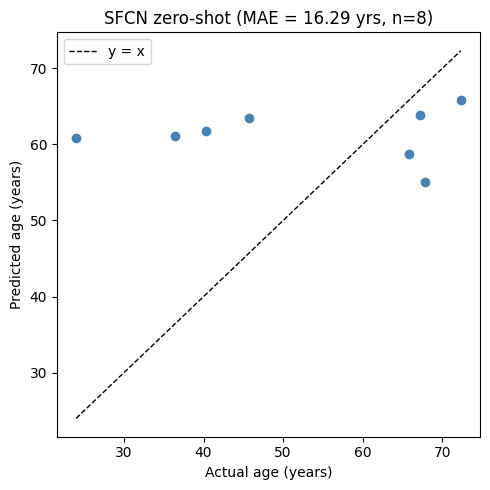

Saved scatter plot to /content/drive/MyDrive/ML_Project/phase3_sfcn_zeroshot_scatter.png


In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(results_df["actual_age"], results_df["predicted_age"], color="steelblue")

lo = min(results_df["actual_age"].min(), results_df["predicted_age"].min())
hi = max(results_df["actual_age"].max(), results_df["predicted_age"].max())
ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="y = x")

ax.set(xlabel="Actual age (years)", ylabel="Predicted age (years)",
       title=f"SFCN zero-shot (MAE = {mae:.2f} yrs, n={len(results_df)})")
ax.legend()
plt.tight_layout()

plot_path = PROJECT_DIR / "phase3_sfcn_zeroshot_scatter.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved scatter plot to {plot_path}")

In [10]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/ML_Project")

print("Drive exists:", Path("/content/drive").exists())
print("MyDrive exists:", Path("/content/drive/MyDrive").exists())
print("Project exists:", PROJECT_DIR.exists())

Drive exists: True
MyDrive exists: True
Project exists: True


In [11]:
from pathlib import Path

print(list(Path("/content/drive/MyDrive").iterdir())[:20])

[PosixPath('/content/drive/MyDrive/2. Class IX POLYNOMIALS.pdf'), PosixPath('/content/drive/MyDrive/Maths Class 9 Notes for Statistics.pdf'), PosixPath('/content/drive/MyDrive/Screenshot_20201029-093724.jpeg'), PosixPath('/content/drive/MyDrive/tamil.pdf'), PosixPath('/content/drive/MyDrive/If I were you animated video(3D)'), PosixPath('/content/drive/MyDrive/ctt-qqwv-tyw – 1 Dec 2020.pdf'), PosixPath('/content/drive/MyDrive/chem Allan laup nalla'), PosixPath('/content/drive/MyDrive/IMG_20201130_140007.jpg'), PosixPath('/content/drive/MyDrive/sc1.jpg'), PosixPath('/content/drive/MyDrive/congruency'), PosixPath('/content/drive/MyDrive/Untitled Jam (7).pdf'), PosixPath('/content/drive/MyDrive/Untitled Jam (6).pdf'), PosixPath('/content/drive/MyDrive/Untitled Jam (5).pdf'), PosixPath('/content/drive/MyDrive/Untitled Jam (4).pdf'), PosixPath('/content/drive/MyDrive/Untitled Jam (3).pdf'), PosixPath('/content/drive/MyDrive/Untitled Jam (2).pdf'), PosixPath('/content/drive/MyDrive/Untitled J

In [13]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [14]:
from pathlib import Path

project_dir = Path("/content/drive/MyDrive/ML_Project")

print("Exists:", project_dir.exists())
print("Is directory:", project_dir.is_dir())

if project_dir.exists():
    print("Contents:")
    for p in list(project_dir.iterdir())[:20]:
        print(p)

Exists: True
Is directory: True
Contents:
/content/drive/MyDrive/ML_Project/IXI_demographics.xls
/content/drive/MyDrive/ML_Project/IXI_data
/content/drive/MyDrive/ML_Project/downloads
/content/drive/MyDrive/ML_Project/ixi_final_metadata.csv
/content/drive/MyDrive/ML_Project/phase1_final_summary.png
/content/drive/MyDrive/ML_Project/IXI_preprocessed
/content/drive/MyDrive/ML_Project/ixi_preprocessed_metadata.csv
/content/drive/MyDrive/ML_Project/ixi_train.csv
/content/drive/MyDrive/ML_Project/ixi_val.csv
/content/drive/MyDrive/ML_Project/ixi_test.csv
/content/drive/MyDrive/ML_Project/phase2_preprocessing_spotcheck.png
/content/drive/MyDrive/ML_Project/phase3_sfcn_zeroshot_scatter.png


## 8. Decision

In [15]:
results_df.to_csv(
    PROJECT_DIR / "phase3_sfcn_zeroshot_results.csv",
    index=False
)

print("Decision rule (implementation.md, Section 3):")

print("  Plausible predictions, roughly tracking real age -> proceed with SFCN (Phase 4)")

print("  Fails to load / crashes / nonsensical predictions -> switch to DeepBrainNet")

print()

print(f"Observed zero-shot MAE: {mae:.2f} years (n={len(results_df)})")

print("Reference: SFCN's reported UK Biobank test MAE = 2.14 +/- 0.05 years")

print(f"Results saved to: {PROJECT_DIR / 'phase3_sfcn_zeroshot_results.csv'}")

Decision rule (implementation.md, Section 3):
  Plausible predictions, roughly tracking real age -> proceed with SFCN (Phase 4)
  Fails to load / crashes / nonsensical predictions -> switch to DeepBrainNet

Observed zero-shot MAE: 16.29 years (n=8)
Reference: SFCN's reported UK Biobank test MAE = 2.14 +/- 0.05 years
Results saved to: /content/drive/MyDrive/ML_Project/phase3_sfcn_zeroshot_results.csv
